# Shoreline change trends from CASSIE shorelines - Narrabeen

In [1]:
overwrite = True

## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import pickle
from shapely import get_coordinates

import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.crs as ccrs

from coastal_data import CD_combine_data, CD_geometry, CD_visualisation, CD_statistics, CD_helper_functions

from coastsat import SDS_transects

In [3]:
epsg_local = 32356

In [4]:
path_shorelines = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/input/'
path_dem = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/output/'
path_tides = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/01_tides/output/'
path_altimetry_output = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/31_Narra_altimetry/output/'

path_output = '/media/bene/Seagate/PhD-data/98_paper2_kf_dtm/14_24_34_RS_shoreline_changes/output/'

In [31]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

### Get data

In [5]:
# Altimetry
fn = 'tp_plus_ales_epsg32356.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [6]:
# Cassie shorelines
folders = ['2_1992-09-24_1998-04-18_spac100_ext400_thresh0/',
          '3_1998-05-20_2007-09-18_spac100_ext400_thresh0/',
          '4_2007-10-04_2016-10-28_spac100_ext400_thresh0/',
          '5_2016-11-13_2021-10-26_spac100_ext400_thresh0/',
          '6_2021-12-13_2025-04-20_spac100_ext300_thresh0/']
sl_cassie = CD_combine_data.combine_cassie(path_shorelines+'1_shorelines_cassie/', folders, epsg=epsg_local)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]
sl_cassie_red = {'dates': c_dates, 'shorelines': c_shorelines}

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

263 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 115 points (min: 34, max: 143).


### Create transects

In [7]:
med_sl = pickle.load(open(path_dem + 'med_sl4326.pkl', 'rb'))
# med_sl = CD_geometry.switch_linestring_xy(med_sl)
med_sl = CD_geometry.transform_linestring(med_sl, 4326, epsg_local)
med_sl = CD_geometry.smooth_LineString(med_sl, n=25)

In [8]:
transects = CD_geometry.create_transects(med_sl, spacing=1000, transect_length=1000, save_path=None, save_fn=None)
print(f'Created {len(transects)} transects.')

transects = transects['transect'][0:-1:3].reset_index()
print(f'Reduced to {len(transects)} transects.')

transect_coords = {i: get_coordinates(transect) for i, transect in enumerate(transects['transect'])}
# switch start and end point of the transects
for key in transect_coords:
    transect_coords[key] = transect_coords[key][::-1]

Created 175 transects.
Reduced to 58 transects.


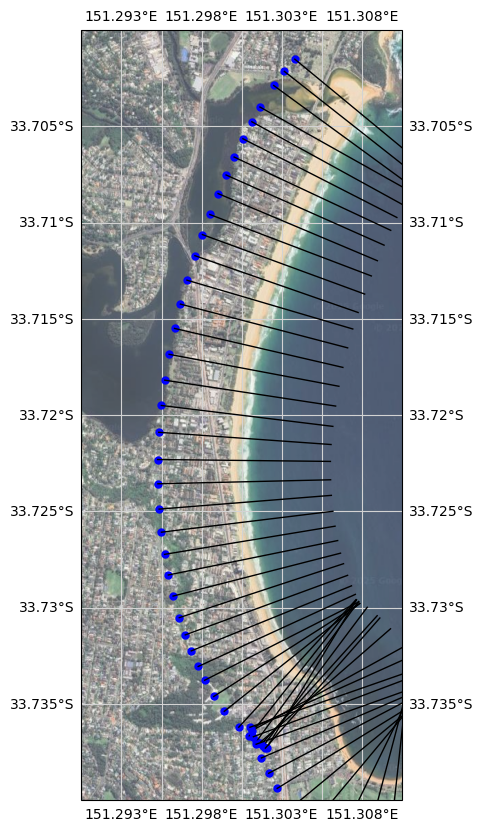

In [9]:
projection = ccrs.epsg(epsg_local)
extent = [151.29, 151.31, -33.74, -33.70]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)
for key in list(transect_coords.keys()):
    # origins, need to be landwards for coastsat intersection computation
    ax.plot(transect_coords[key][0,0],transect_coords[key][0,1], 'bo', ms=5, transform=projection)
    ax.plot(transect_coords[key][:,0],transect_coords[key][:,1],'k-',lw=1, transform=projection)

### Compute intersections

In [10]:
fn_cd = 'cd_cassie_sm_Narra.pkl'
if (not os.path.isfile(path_output + fn_cd)) | overwrite:
    settings_transects = {
                'along_dist': 1200,     # along-shore distance to use for computing the intersection
                'max_dist_origin': 10000,     # maximum distance to the origin of a transect in [m]
                             }
    cd_cassie = SDS_transects.compute_intersection(sl_cassie_red, transect_coords, settings_transects)
    
    cd_cassie_sm = {}
    for key in cd_cassie.keys():
        # Interpolate over the nans
        cd_cassie[key] = np.array(pd.Series(cd_cassie[key]).interpolate())
        # Smooth
        cd_cassie_sm[key] = CD_statistics.moving_average(cd_cassie[key], 5)
    
    pickle.dump(cd_cassie_sm, open(path_output+fn_cd, 'wb'))
else:
    cd_cassie_sm = pickle.load(open(path_output+fn_cd, 'rb'))
    print(f'Loaded {fn_cd} from {path_output}')

### Tide correction

In [35]:
# Tide model
fn = 'tides_narra.csv'
tidal_corr = pd.read_csv(path_tides+fn, index_col='dates', parse_dates=['dates'])

# Interpolate tides onto cassie time stamps
dates_tides = CD_helper_functions.datetime_to_decimal_numbers(tidal_corr.index)
dates_cassie = CD_helper_functions.datetime_to_decimal_numbers(pd.to_datetime(c_dates))

tides_at_cassie_times = np.interp(dates_cassie, dates_tides, tidal_corr['corr_eot[m]'])

beach_slope = -0.1
cd_tcorr = CD_combine_data.tidal_correction(cd_cassie_sm, tides_at_cassie_times, beach_slope)

### Plots

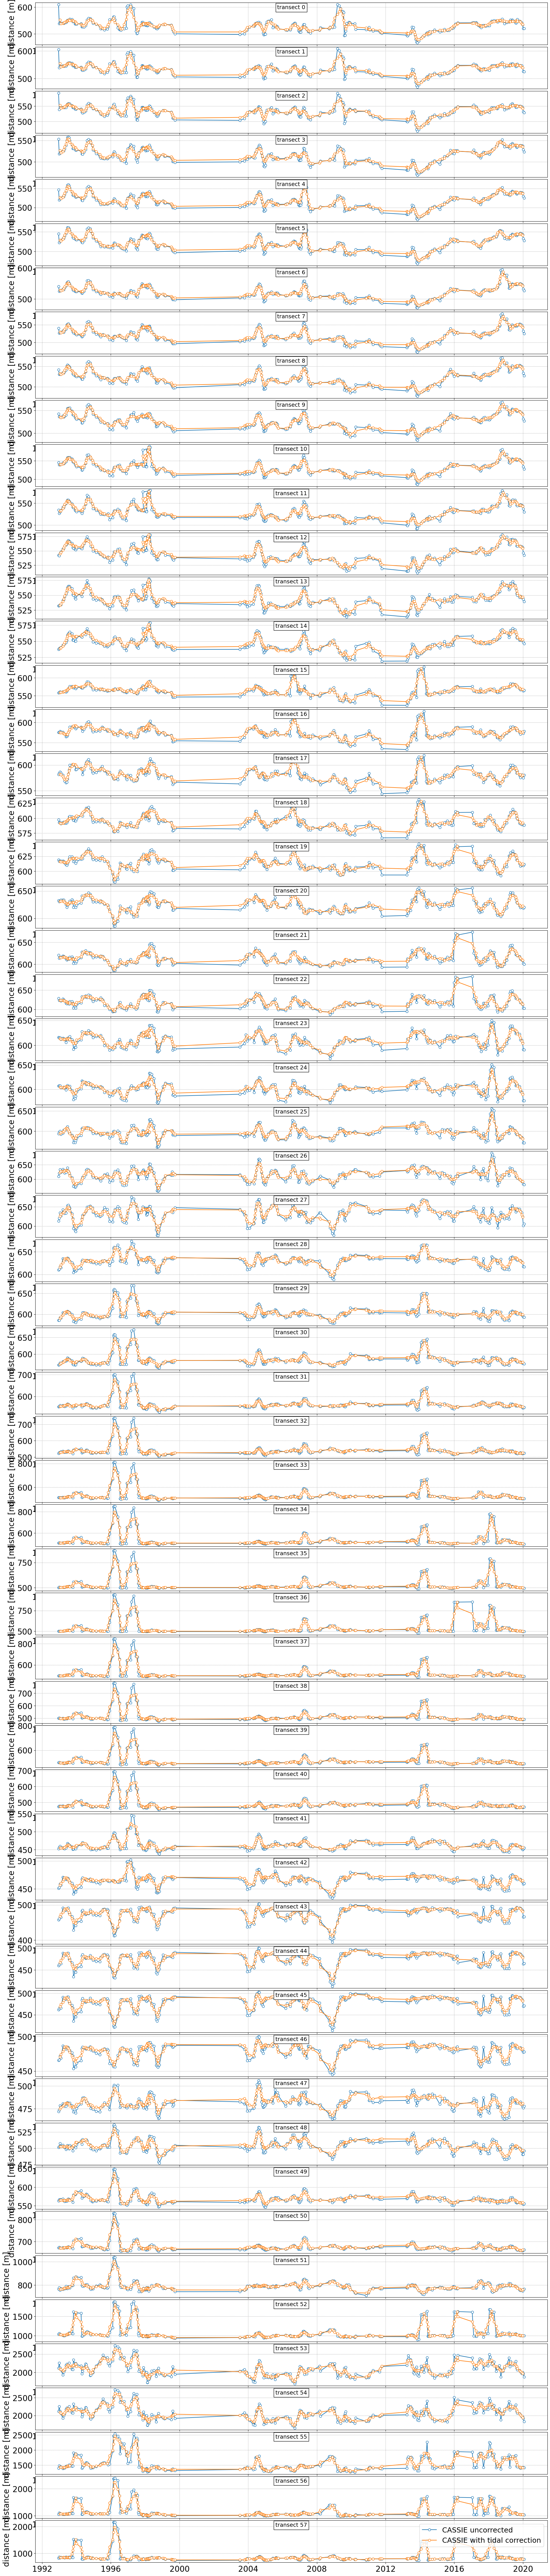

In [36]:
# plot timeseries for all transects
fig = plt.figure(figsize=[20,100])
gs = gridspec.GridSpec(len(cd_tcorr),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(cd_tcorr.keys()):
    if np.all(np.isnan(cd_tcorr[key])):
        continue
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    
    ax.plot(c_dates, cd_cassie_sm[key], '-o', ms=6, mfc='w', label='CASSIE uncorrected')
    ax.plot(c_dates, cd_tcorr[key], '-o', ms=6, mfc='w', label='CASSIE with tidal correction')
    
    ax.set_ylabel('distance [m]')
    ax.text(0.5,0.95, f'transect {key}', bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center', va='top', transform=ax.transAxes, fontsize=14)
ax.legend(loc='upper right', fontsize='large');

### Trends

In [37]:
trend_all, trend_all_tcorr = [], []
for transect in cd_cassie_sm.keys():
    trend_all.append(CD_statistics.compute_trend(dates_cassie, cd_cassie_sm[transect]))
    trend_all_tcorr.append(CD_statistics.compute_trend(dates_cassie, cd_tcorr[transect]))

In [38]:
print(f'Entire coastline, median trend: {round(np.median(trend_all_tcorr),2)} m/year, mean trend: {round(np.mean(trend_all_tcorr),2)} m/year')

Entire coastline, median trend: -0.25 m/year, mean trend: -0.25 m/year


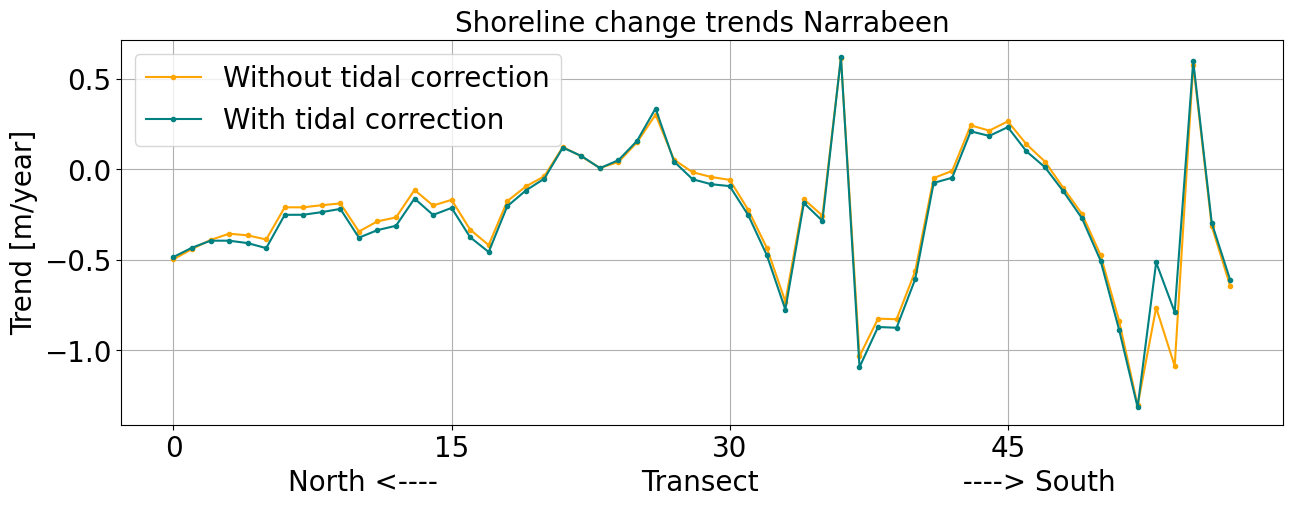

In [39]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(cd_cassie_sm.keys(), trend_all, '.-', label='Without tidal correction', color='orange')
ax.plot(cd_cassie_sm.keys(), trend_all_tcorr, '.-', label='With tidal correction', color='teal')

ax.legend()
ax.set_ylabel('Trend [m/year]')
ax.set_xlabel('North <----                       Transect                       ----> South')
xticks = list(cd_cassie_sm.keys())[0::15]
ax.set_xticks(xticks)
ax.set_title('Shoreline change trends Narrabeen')
ax.grid()

plt.savefig(f'{path_output}Ters_RS_shoreline_trends.png', dpi=300, bbox_inches='tight')